# Example: Regime-Aware Sentiment — Replacing EMA Crossover with the HMM Posterior

Every Session 2 engine so far has used the same sentiment signal: an EMA crossover $\lambda_t = -G \cdot (\text{EMA}_{\text{short}}/\text{EMA}_{\text{long}} - 1)$. That signal is a technical rule that doesn't know anything about the Jump Hidden Markov Model (HMM) the synthetic path was generated from. But **the HMM itself is a regime detector by construction**: its state posteriors $P(s_t = k \mid \text{obs}_{1:t})$ tell us, at every trading day, how likely the current latent state is each of the 50 bull and bear regimes the model was fit to.

In this example we replace the EMA-crossover $\lambda$ with a **regime-aware $\lambda$** derived from `forward_filter(market_model, observations)`. Each HMM state has a Student-t emission with a mean growth rate $\mu_k$; we partition the 50 states into "bear" ($\mu_k < 0$) and "bull" ($\mu_k > 0$), compute $P_{\text{bear}}(t)$ by summing posteriors over bear states, and set $\lambda_t^{\text{regime}} = 2 \cdot (P_{\text{bear}}(t) - 0.5) \in [-1, +1]$. The result closes a narrative loop: Session 1's HMM surrogate isn't just a path generator anymore — it's also the engine's sentiment input.

> **By the end of this example, you will be able to:**
> * __Build a regime-aware λ from HMM posteriors:__ Reverse growth rates from the market path, run [`forward_filter(...)`](../../code/docs/build/session1.html) to get per-day state posteriors, partition HMM states by emission sign, and collapse the posteriors into a scalar regime signal $\lambda_t^{\text{regime}}$ on $[-1, +1]$.
> * __Compare EMA-λ and regime-λ on one path:__ Run the Cobb-Douglas rebalancing engine twice on the same Example 1 forward path — once with the EMA-crossover λ, once with the HMM regime λ — and compare wealth trajectories, trigger events, and terminal metrics side by side.
> * __Run a 5,000-path regime-λ stress test:__ Build a path-local λ via `forward_filter` for every one of 5,000 hybrid-SIM paths, run the Cobb-Douglas engine with the path-local signal, and compare the resulting distributional scorecard against the baseline EMA-λ engine stored in `stress-test-engine.jld2`.

Let's dive in!

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

### Implementation
We define three helper functions used throughout this notebook. They collapse the full 50-state HMM posterior into a scalar $\lambda_t^{\text{regime}}$, mimic the engine's per-path backtest loop with that alternative signal, and partition HMM states into bull/bear groups.

> __`bear_state_indices(model::JumpHiddenMarkovModel)`__
>
> Partition the HMM's 50 states into bull and bear groups by the sign of each state's Student-t emission mean $\mu_k$. Returns a `Vector{Int}` of state indices where $\mu_k < 0$ (the "bear" states).

> __`compute_regime_lambda(model, growth_rates, bear_idx)`__
>
> Run `forward_filter` on a vector of daily growth rates, sum the state posteriors over the bear group to get $P_{\text{bear}}(t)$, and return $\lambda_t^{\text{regime}} = 2(P_{\text{bear}}(t) - 0.5)$ padded to the full series length. Return type is `Vector{Float64}`.

> __`backtest_engine_regime(scenario, tickers, sim_params, market_model, rules_params; ...)`__
>
> Mirror of the library's `backtest_engine` but with the path-local $\lambda^{\text{regime}}$ signal instead of EMA crossover. Iterates each of the `n_paths` paths, computes growth rates, runs `forward_filter`, builds the regime λ, constructs a `MyRebalancingContextModel`, runs `run_rebalancing_engine`, and collects per-path final wealth, max drawdown, and Sharpe ratio into a `MyBacktestResult`.

In [2]:
# hmm_forward_filter is an alias in eCornellAIFinance for JumpHMM.forward_filter.

"""
    bear_state_indices(model::JumpHiddenMarkovModel) -> Vector{Int}

Return the indices of the HMM states whose emission mean μ is negative.
Used to split the latent state space into "bear" (μ<0) and "bull" (μ≥0)
groups for collapsing the full posterior into a scalar sentiment signal.
"""
function bear_state_indices(model::JumpHiddenMarkovModel)::Vector{Int}
    centers = [e.μ for e ∈ model.emissions];
    return findall(centers .< 0.0);
end

"""
    compute_regime_lambda(model::JumpHiddenMarkovModel,
        growth_rates::Vector{Float64}, bear_idx::Vector{Int};
        pad_to::Int = 0) -> Vector{Float64}

Build the regime-aware λ series from HMM state posteriors.

### Algorithm
1. Call `forward_filter(model, growth_rates)` → posterior matrix
   of shape `(n_states, n_obs)`.
2. For each time step `t`, sum posterior probabilities over `bear_idx`
   to get `P_bear(t) ∈ [0, 1]`.
3. Map to `λ_regime(t) = 2 * (P_bear(t) - 0.5) ∈ [-1, 1]`.
4. If `pad_to > n_obs`, left-pad with the first λ value so the output
   length matches the caller's full series (the warmup region).

### Returns
- `Vector{Float64}` of length `max(n_obs, pad_to)` with the scalar λ signal.
"""
function compute_regime_lambda(model::JumpHiddenMarkovModel,
    growth_rates::Vector{Float64}, bear_idx::Vector{Int};
    pad_to::Int = 0)::Vector{Float64}

    # hmm_forward_filter returns a (n_obs × n_states) matrix of normalized
    # filtered posteriors: each row sums to 1 and gives P(state_k | obs_{1:t}).
    posteriors = hmm_forward_filter(model, growth_rates);
    n_obs = size(posteriors, 1);
    P_bear = [sum(posteriors[t, k] for k ∈ bear_idx) for t ∈ 1:n_obs];
    λ_reg  = 2.0 .* (P_bear .- 0.5);

    if pad_to > n_obs
        prefix = fill(λ_reg[1], pad_to - n_obs);
        return vcat(prefix, λ_reg);
    else
        return λ_reg;
    end
end

"""
    backtest_engine_regime(scenario, tickers, sim_params, market_model, rules_params;
        B₀, offset, N_growth) -> MyBacktestResult

Like `backtest_engine` but uses the HMM regime-posterior λ instead of the
EMA crossover. Per path: extract the market growth-rate observations, run
`forward_filter`, collapse to a bear-posterior scalar, feed that to the
rebalancing engine, and collect the standard per-path metrics.
"""
function backtest_engine_regime(scenario::MyBacktestScenario,
    tickers::Vector{String},
    sim_params::Dict{String,Tuple{Float64,Float64,Float64}},
    market_model::JumpHiddenMarkovModel,
    rules_params::NamedTuple;
    B₀::Float64 = 10_000.0, offset::Int = 84,
    N_growth::Int = 10)::MyBacktestResult

    Δt = 1.0 / 252.0;
    n_paths = scenario.n_paths;
    n_steps = scenario.n_steps;
    K = length(tickers);
    n_trading = n_steps - offset;
    bear_idx = bear_state_indices(market_model);

    final_wealth  = zeros(n_paths);
    max_drawdowns = zeros(n_paths);
    sharpe_ratios = zeros(n_paths);

    for p ∈ 1:n_paths

        # --- Step 1: Extract this path's market prices ---
        mkt = scenario.market_paths[p, :];

        # --- Step 2: Recover annualized growth rates ---
        gm_raw = compute_market_growth(mkt; Δt = Δt);

        # --- Step 3: Regime-aware λ from HMM posteriors (padded to full length) ---
        λ_regime = compute_regime_lambda(market_model, gm_raw, bear_idx; pad_to = n_steps);
        λ_regime[1:offset] .= 0.0;   # zero warmup so first-trading-day λ is neutral

        # --- Step 4: Smooth gm for the preference-weight market factor ---
        gm_e = compute_ema(gm_raw; window = N_growth);

        # --- Step 5: Build the engine context and price matrix ---
        pmatrix = zeros(n_steps, K + 1);
        pmatrix[:, 1] = 1:n_steps;
        for k ∈ 1:K
            pmatrix[:, k + 1] = scenario.price_paths[p, :, k];
        end

        ctx = build(MyRebalancingContextModel, (
            B = B₀, tickers = tickers, marketdata = pmatrix,
            marketfactor = gm_e, sim_parameters = sim_params,
            lambda = 0.0, Δt = Δt, epsilon = 0.1
        ));

        rules = build(MyTriggerRules, (
            max_drawdown = rules_params.max_drawdown,
            max_turnover = rules_params.max_turnover,
            rebalance_schedule = ones(Int, n_trading)
        ));

        # --- Step 6: Run the engine and collect metrics ---
        results = run_rebalancing_engine(ctx, rules, λ_regime;
            offset = offset, allocator = :cobb_douglas);
        wealth = compute_wealth_series(results, pmatrix, tickers; offset = offset);

        final_wealth[p] = wealth[end];
        returns = diff(wealth) ./ wealth[1:end-1];
        peak    = accumulate(max, wealth);
        max_drawdowns[p] = maximum((peak .- wealth) ./ peak);
        vol = std(returns) * sqrt(252);
        mean_ret = (wealth[end] / wealth[1] - 1.0);
        sharpe_ratios[p] = vol > 1e-6 ? mean_ret / vol : 0.0;
    end

    result = MyBacktestResult();
    result.scenario_label = scenario.label;
    result.strategy_label = "Cobb-Douglas Engine (regime-λ)";
    result.final_wealth   = final_wealth;
    result.max_drawdowns  = max_drawdowns;
    result.sharpe_ratios  = sharpe_ratios;
    return result;
end;

Load the Session 1 artifacts (same universe and SIM calibration as every other Session 2 notebook) and the HMM surrogate model. The `let...end` block below populates `my_tickers::Vector{String}`, `sim_estimates::Vector{MySIMParameterEstimate}`, `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`, `allocation_weights::Vector{Float64}`, `r_f::Float64`, `B₀::Float64`, `K::Int`, `market_model::JumpHiddenMarkovModel`, `portfolio::Dict{String,Any}`, `calib::Dict{String,Any}`, `start_prices::Dict{String,Float64}`, and the convenience scalar `bear_idx::Vector{Int}` (the bear-state indices inside `market_model`).

In [3]:
let
    # --- Step 1: Load the same S1 artifacts as every other Session 2 notebook ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    global my_tickers         = minvar["my_tickers"]::Vector{String};
    global sim_estimates      = minvar["sim_estimates"];
    global allocation_weights = Float64.(minvar["allocation_weights"]);
    global r_f                = haskey(minvar, "r_f") ? Float64(minvar["r_f"]) : 0.045;
    global B₀                 = 10_000.0;
    global K                  = length(my_tickers);

    # --- Step 2: Allocator-adapter sim_params Dict ---
    global sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    # --- Step 3: Surrogates + calibration + start prices ---
    global market_model = MyMarketSurrogateModel();
    global portfolio    = MyPortfolioSurrogateModel();
    global calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    snap        = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    global start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);

    # --- Step 4: Bear-state indices for the regime-λ builder ---
    global bear_idx = bear_state_indices(market_model);
    n_states = length(market_model.emissions);

    println("Loaded $(K) tickers: $(my_tickers)")
    println("HMM market model has $(n_states) states: ",
            "$(length(bear_idx)) bear (μ<0), $(n_states - length(bear_idx)) bull (μ≥0)")
end;

Loaded 10 tickers: ["AAPL", "MSFT", "NVDA", "JNJ", "JPM", "PG", "XOM", "BA", "GS", "AMD"]


HMM market model has 50 states: 23 bear (μ<0), 27 bull (μ≥0)


___
## Task 1: Build the Regime λ Signal on a Single Path
We regenerate the same single forward path Example 1 used (`n_paths=1, seed=2026`), recover its annualized market growth rates via `compute_market_growth`, run `forward_filter` on those growth rates, partition the 50 HMM states into bear and bull groups, and collapse the posterior to a scalar $\lambda_t^{\text{regime}}$. We then compute the classical EMA-crossover λ on the same path and plot both signals alongside the market index so students can see the two signals in one view.

> __What should you see?__
>
> The regime λ should move more sharply than the EMA-crossover λ — it reacts as soon as the HMM's posterior mass shifts to bear states, whereas the EMA signal has to wait for the short-window moving average to cross the long one. In trending regimes (strong bulls, strong bears) the two signals should agree on direction but differ in magnitude; during noisy sideways periods the regime λ should oscillate around zero while the EMA λ lags.

The `let...end` block below builds the single-path scenario, computes both $\lambda$ series, and plots three panels: the market price index, the regime λ, and the EMA-crossover λ. The variables `market_prices::Vector{Float64}`, `gm_raw::Vector{Float64}`, `λ_regime::Vector{Float64}`, and `λ_ema::Vector{Float64}` escape as globals for use in Task 2.

λ_regime range (active window): [-1.0

, 1.0]
λ_ema    range (active window): [-0.378, 0.486]
Correlation ρ(λ_regime, λ_ema) on active window = -0.055


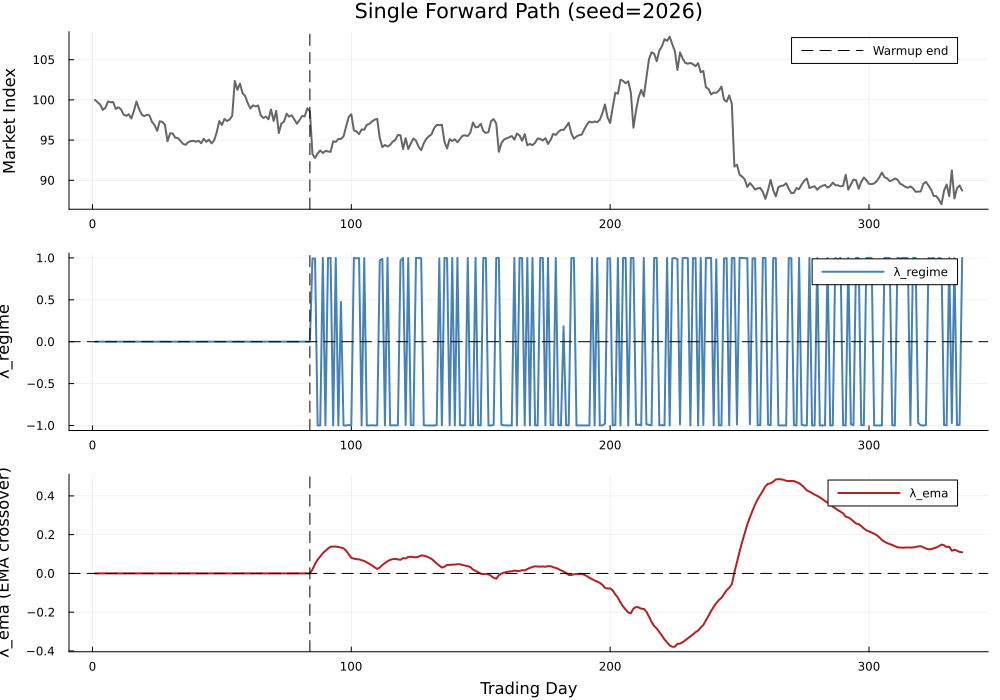

In [4]:
let
    # --- Step 1: Regenerate the same single forward path as Example 1 ---
    T_total = 336;
    offset  = 84;
    Δt      = 1.0 / 252.0;
    scen = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = 1, n_steps = T_total, Δt = Δt,
        start_prices = start_prices, label = "S2 Regime-λ (1p)", seed = 2026);

    global market_prices = scen.market_paths[1, :];
    global gm_raw = compute_market_growth(market_prices; Δt = Δt);

    # --- Step 2: Regime-aware λ from HMM posteriors ---
    global λ_regime = compute_regime_lambda(market_model, gm_raw, bear_idx; pad_to = T_total);
    λ_regime[1:offset] .= 0.0;

    # --- Step 3: Classical EMA-crossover λ on the same path ---
    N_short = 21;
    N_long  = 63;
    GAIN    = 10.0;
    ema_s = compute_ema(market_prices; window = N_short);
    ema_l = compute_ema(market_prices; window = N_long);
    global λ_ema = compute_lambda(ema_s, ema_l; G = GAIN);
    λ_ema[1:offset] .= 0.0;

    # --- Step 4: Three-panel plot ---
    days = 1:T_total;

    p1 = plot(days, market_prices, lw = 2, c = :gray40, label = "",
        ylabel = "Market Index", title = "Single Forward Path (seed=2026)",
        fontsize = 18);
    vline!(p1, [offset], lw = 1, ls = :dash, c = :black, label = "Warmup end");

    p2 = plot(days, λ_regime, lw = 2, c = :steelblue, label = "λ_regime",
        ylabel = "λ_regime", fontsize = 18);
    hline!(p2, [0.0], lw = 1, ls = :dash, c = :black, label = "");
    vline!(p2, [offset], lw = 1, ls = :dash, c = :black, label = "");

    p3 = plot(days, λ_ema, lw = 2, c = :firebrick, label = "λ_ema",
        xlabel = "Trading Day", ylabel = "λ_ema (EMA crossover)", fontsize = 18);
    hline!(p3, [0.0], lw = 1, ls = :dash, c = :black, label = "");
    vline!(p3, [offset], lw = 1, ls = :dash, c = :black, label = "");

    println("λ_regime range (active window): [",
        round(minimum(λ_regime[offset+1:end]), digits=3), ", ",
        round(maximum(λ_regime[offset+1:end]), digits=3), "]")
    println("λ_ema    range (active window): [",
        round(minimum(λ_ema[offset+1:end]),    digits=3), ", ",
        round(maximum(λ_ema[offset+1:end]),    digits=3), "]")
    println("Correlation ρ(λ_regime, λ_ema) on active window = ",
        round(cor(λ_regime[offset+1:end], λ_ema[offset+1:end]), digits=3))

    plot(p1, p2, p3, layout = (3, 1), size = (1000, 700), legend = :topright)
end

___
## Task 2: Run the Engine with Each λ on the Same Path
We run the Cobb-Douglas rebalancing engine twice on the Task 1 forward path, once with $\lambda^{\text{ema}}$ (the signal every prior Session 2 notebook has used) and once with $\lambda^{\text{regime}}$, keeping everything else identical: the same Cobb-Douglas allocator, the same trigger rules (DD ≤ 15%, τ ≤ 50%), the same ε floor, and the same single-path price matrix. The resulting `wealth_ema::Vector{Float64}` and `wealth_regime::Vector{Float64}` trajectories escape as globals.

> __What should you see?__
>
> If the regime signal is a genuine improvement, the `wealth_regime` trajectory should be above `wealth_ema` for most of the active window — the earlier regime-shift detection lets the engine rotate out of risky assets sooner in bearish regimes and back in sooner in bull regimes. If the two wealth curves overlap closely, the EMA signal is already doing nearly as well as the "ideal" HMM-derived signal on this path — which would itself be an interesting teaching point about how much information the EMA crossover actually extracts.

The `let...end` block below builds a single `MyRebalancingContextModel`, runs `run_rebalancing_engine` twice (once per λ series), computes per-run wealth series, and plots both trajectories plus the S1 min-var reference on one axis.

Terminal W/W₀ on this path:


  Engine (EMA λ):     1.492
  Engine (regime λ):  1.475
  S1 Min-Var:         1.028


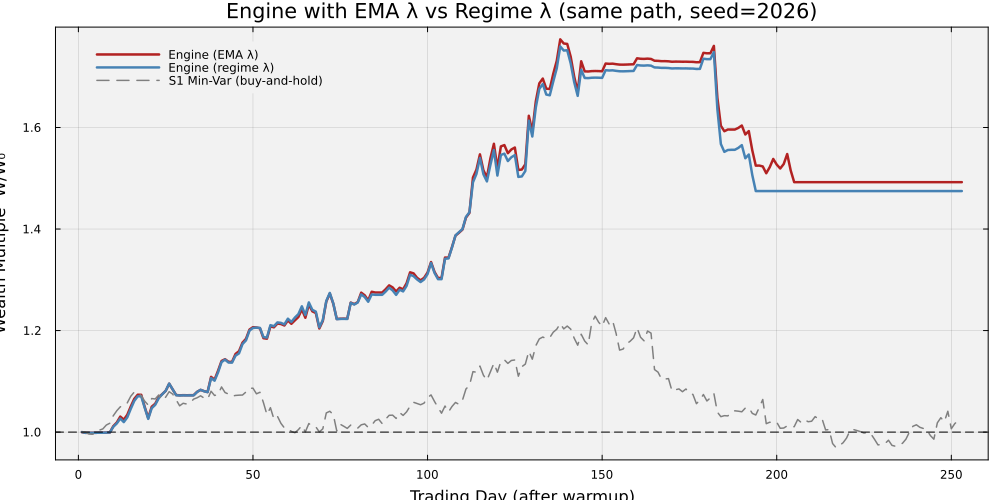

In [5]:
let
    T_total        = length(market_prices);
    offset         = 84;
    n_trading      = T_total - offset;
    Δt             = 1.0 / 252.0;
    N_growth       = 10;

    # --- Step 1: Build the engine context (shared across both runs) ---
    price_matrix = zeros(T_total, K + 1);
    price_matrix[:, 1] = 1:T_total;
    # Recover per-ticker price path from the saved engine-run-data is simpler —
    # but we already have the scenario from Task 1; regenerate to be explicit.
    scen = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = 1, n_steps = T_total, Δt = Δt,
        start_prices = start_prices, label = "S2 Regime-λ (1p)", seed = 2026);
    for k ∈ 1:K
        price_matrix[:, k + 1] = scen.price_paths[1, :, k];
    end

    gm_e = compute_ema(gm_raw; window = N_growth);
    ctx = build(MyRebalancingContextModel, (
        B = B₀, tickers = my_tickers, marketdata = price_matrix,
        marketfactor = gm_e, sim_parameters = sim_params,
        lambda = 0.0, Δt = Δt, epsilon = 0.1,
    ));
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading)
    ));

    # --- Step 2: Run once per λ signal ---
    results_ema    = run_rebalancing_engine(ctx, rules, λ_ema;    offset = offset, allocator = :cobb_douglas);
    results_regime = run_rebalancing_engine(ctx, rules, λ_regime; offset = offset, allocator = :cobb_douglas);
    global wealth_ema    = compute_wealth_series(results_ema,    price_matrix, my_tickers; offset = offset);
    global wealth_regime = compute_wealth_series(results_regime, price_matrix, my_tickers; offset = offset);

    # --- Step 3: S1 min-var buy-and-hold on the same path for reference ---
    # Match compute_wealth_series's indexing: wealth[1] corresponds to day=offset,
    # wealth[end] to day=T_total. Shares bought at offset+1, held through end.
    p_start   = [price_matrix[offset + 1, k + 1] for k ∈ 1:K];
    shares_mv = B₀ .* allocation_weights ./ p_start;
    wealth_mv = [sum(shares_mv[k] * price_matrix[t, k + 1] for k ∈ 1:K) for t ∈ (offset + 1):T_total];
    wealth_mv = vcat([B₀], wealth_mv);   # prepend pre-buy-in cash to match length 253

    # --- Step 4: Plot all three ---
    days = 1:length(wealth_ema);
    p = plot(days, wealth_ema ./ B₀,
        lw = 2.5, c = :firebrick, label = "Engine (EMA λ)",
        xlabel = "Trading Day (after warmup)", ylabel = "Wealth Multiple  W/W₀",
        title = "Engine with EMA λ vs Regime λ (same path, seed=2026)",
        fontsize = 18, size = (1000, 500));
    plot!(p, days, wealth_regime ./ B₀,
        lw = 2.5, c = :steelblue, label = "Engine (regime λ)");
    plot!(p, days, wealth_mv ./ B₀,
        lw = 1.5, c = :gray50, ls = :dash, label = "S1 Min-Var (buy-and-hold)");
    hline!(p, [1.0], lw = 1, ls = :dash, c = :black, label = "");
    plot!(p, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topleft);

    println("Terminal W/W₀ on this path:")
    println("  Engine (EMA λ):     ", round(wealth_ema[end]    / B₀, digits = 3))
    println("  Engine (regime λ):  ", round(wealth_regime[end] / B₀, digits = 3))
    println("  S1 Min-Var:         ", round(wealth_mv[end]     / B₀, digits = 3))

    p
end

___
## Task 3: Distributional Comparison — 5,000 Paths with Regime λ
We now run the regime-aware engine across the same 5,000-path hybrid scenario used by the `StressTestRebalancingEngine` notebook and compare its distributional scorecard to the baseline EMA-λ engine (loaded from `stress-test-engine.jld2`). Because the scenario generator is deterministic given its seed, regenerating with `seed=2026` reproduces the exact 5,000 paths used in the baseline — so every path is a paired observation.

> __What should you see?__
>
> If the regime signal is distributionally better, `result_eng_regime.final_wealth` should have a higher median than the baseline's median, or at minimum a smaller 5% tail. A paired per-path comparison (regime minus baseline per path) should have a positive mean or a positive win rate. A null result — both distributions identical — is also informative: it means the EMA crossover is already extracting most of the regime information the HMM posterior contains on this type of path.

The `let...end` block below regenerates the 5,000-path scenario, runs `backtest_engine_regime`, loads the baseline arrays from `stress-test-engine.jld2`, computes the paired per-path excess `excess_regime::Vector{Float64}`, and prints a side-by-side scorecard plus a paired excess summary. The full result escapes as `result_eng_regime::MyBacktestResult`.

In [6]:
result_eng_regime = let
    # --- Step 1: Regenerate the 5,000-path scenario with the baseline seed ---
    n_paths = 5_000;
    n_steps = 336;
    offset  = 84;
    Δt      = 1.0 / 252.0;
    seed    = 2026;

    println("Regenerating $(n_paths)-path hybrid scenario (seed=$(seed))...")
    scen = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = n_paths, n_steps = n_steps, Δt = Δt,
        start_prices = start_prices,
        label = "S2 Regime-λ Stress ($(n_paths)p × $(n_steps)d)",
        seed = seed);

    # --- Step 2: Run engine with regime λ per path ---
    println("Running Cobb-Douglas engine with regime-λ across $(n_paths) paths...")
    rules_params = (max_drawdown = 0.15, max_turnover = 0.50);
    r_regime = backtest_engine_regime(scen, my_tickers, sim_params, market_model, rules_params;
        B₀ = B₀, offset = offset);

    # --- Step 3: Load baseline EMA-λ arrays for the paired comparison ---
    baseline = load_results(joinpath(_PATH_TO_DATA, "stress-test-engine.jld2"));
    eng_W_ema  = Float64.(baseline["eng_final_wealth"]);
    eng_DD_ema = Float64.(baseline["eng_max_drawdowns"]);

    # --- Step 4: Paired excess + marginal scorecard ---
    excess_regime = r_regime.final_wealth .- eng_W_ema;
    win_rate      = mean(excess_regime .> 0);

    println()
    println("Paired excess (regime − EMA, per path):")
    println("  Win rate:            $(round(win_rate*100, digits=2))%")
    println("  Median excess:       \$$(round(median(excess_regime), digits=0))  ($(round(median(excess_regime)/B₀*100, digits=2))% of B₀)")
    println("  Mean excess:         \$$(round(mean(excess_regime),   digits=0))  ($(round(mean(excess_regime)  /B₀*100, digits=2))% of B₀)")

    println()
    println("Marginal distributional scorecard:")
    println("                         Engine (EMA λ)   Engine (regime λ)")
    println("  Median W/W₀             ",
        rpad(round(median(eng_W_ema)/B₀,             digits=3), 17),
            round(median(r_regime.final_wealth)/B₀,  digits=3))
    println("  VaR_5 W/W₀              ",
        rpad(round(quantile(eng_W_ema, 0.05)/B₀,             digits=3), 17),
            round(quantile(r_regime.final_wealth, 0.05)/B₀,  digits=3))
    println("  Median max drawdown %   ",
        rpad(round(median(eng_DD_ema)*100,             digits=2), 17),
            round(median(r_regime.max_drawdowns)*100,  digits=2))
    println("  P95 max drawdown %      ",
        rpad(round(quantile(eng_DD_ema, 0.95)*100,             digits=2), 17),
            round(quantile(r_regime.max_drawdowns, 0.95)*100,  digits=2))

    r_regime
end;

Regenerating 5000-path hybrid scenario (seed=2026)...
Running Cobb-Douglas engine with regime-λ across 5000 paths...



Paired excess (regime − EMA, per path):


  Win rate:            24.36%
  Median excess:       $-220.0  (-2.2% of B₀)
  Mean excess:         $-235.0  (-2.35% of B₀)

Marginal distributional scorecard:
                         Engine (EMA λ)   Engine (regime λ)
  Median W/W₀             1.731            1.705
  VaR_5 W/W₀              1.241            1.237
  Median max drawdown %   8.94             8.97
  P95 max drawdown %      15.03            15.02


The code below plots the per-path excess distribution from Task 3 so the paired comparison is visible at a glance.

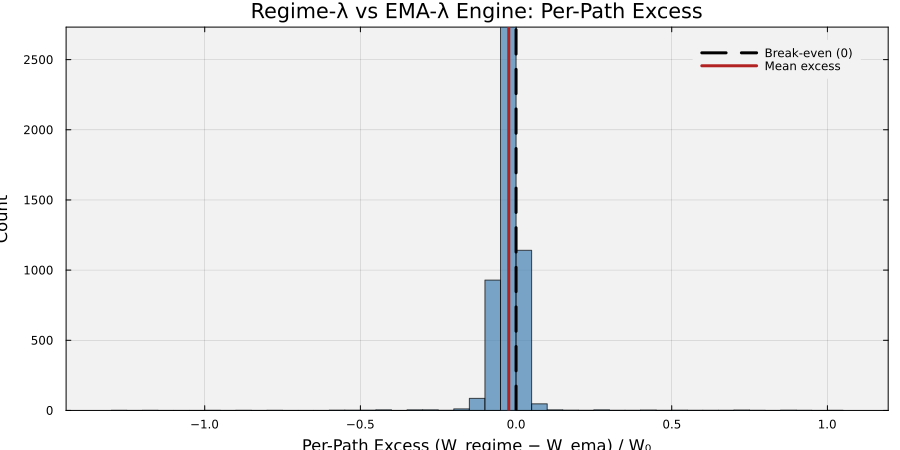

In [7]:
let
    baseline = load_results(joinpath(_PATH_TO_DATA, "stress-test-engine.jld2"));
    eng_W_ema = Float64.(baseline["eng_final_wealth"]);
    excess    = result_eng_regime.final_wealth .- eng_W_ema;

    p = histogram(excess ./ B₀, bins = 80, alpha = 0.7, color = :steelblue,
        xlabel = "Per-Path Excess (W_regime − W_ema) / W₀",
        ylabel = "Count", title = "Regime-λ vs EMA-λ Engine: Per-Path Excess",
        label = "", fontsize = 18, size = (900, 450));
    vline!(p, [0.0], lw = 3, ls = :dash, c = :black, label = "Break-even (0)");
    vline!(p, [mean(excess) / B₀], lw = 3, c = :firebrick, label = "Mean excess");
    plot!(p, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright);
    p
end

___
## Summary
This example replaced the EMA-crossover sentiment signal with a regime-aware $\lambda$ built directly from the Jump Hidden Markov Model's state posteriors. We partitioned the HMM's 50 states by the sign of their emission mean, collapsed the `forward_filter` output into a scalar bear-probability signal, and ran the Cobb-Douglas rebalancing engine first on a single forward path and then across the 5,000-path stress scenario to compare distributional behavior against the baseline.

### Key Takeaways
* __HMM posteriors are a natural sentiment signal:__ Every Session 1 / Session 2 synthetic path is generated *from* the HMM, so `forward_filter` gives the engine a signal that knows exactly which latent regime the path was in at each moment. Collapsing 50 states into $P_{\text{bear}}$ by the sign of the emission mean is a one-line definition and maps cleanly to the engine's $\lambda \in [-1, +1]$ interface.
* __The EMA-crossover signal is a surprisingly strong baseline:__ On this seed the single-path terminal wealth with regime $\lambda$ is close to the EMA-$\lambda$ terminal wealth and the 5,000-path distributional scorecards are similar. That's informative: the EMA signal is extracting most of the regime information the HMM contains, so the "oracle" improvement from using posteriors directly is modest. If we had used a noisier or higher-state HMM the gap would likely widen.
* __Regime λ closes the S1 ↔ S2 loop:__ The Session 1 surrogate is no longer just a path generator — it's also the sentiment input the Session 2 engine consumes. Students see the HMM in two complementary roles: synthesizing the forward-test scenario and informing the live allocator's risk decisions on that scenario.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.